In [1]:
import os, time, gzip, shutil, json
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Layer, Conv2D, MaxPooling2D, Flatten, Dense,
                                     GlobalAveragePooling2D, Reshape, Multiply, Input)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# ----------------------------------------------------------------------------
# Custom ChannelAttention layer (must be identical to training.ipynb so that
# the saved .keras model can be loaded back successfully).
# ----------------------------------------------------------------------------
class ChannelAttention(Layer):
    """Channel Attention Module — same as used in training."""
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels      = input_shape[-1]
        self.gap      = GlobalAveragePooling2D()
        self.dense1   = Dense(max(1, channels // self.ratio), activation="relu")
        self.dense2   = Dense(channels, activation="sigmoid")
        self.reshape  = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

CUSTOM_OBJECTS = {"ChannelAttention": ChannelAttention}


In [2]:
import random, os
import numpy as np
import tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print(f"[INFO] enable_op_determinism: {e}")

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for g in gpus:
        try: tf.config.experimental.set_memory_growth(g, True)
        except RuntimeError: pass
    print(f"GPU detected: {[g.name for g in gpus]}")
else:
    print("Running on CPU.")


TensorFlow version: 2.10.0
GPU detected: ['/physical_device:GPU:0']


In [3]:
# ============================================================================
# UNIFIED EVALUATION HELPERS  (same definitions across all 4 notebooks)
# ============================================================================

def get_file_size_kb(path):
    """File size in KB, or 0.0 if missing."""
    return os.path.getsize(path) / 1024.0 if os.path.exists(path) else 0.0

def fmt_size(kb):
    if kb < 1024: return f"{kb:.2f} KB"
    return f"{kb/1024:.2f} MB"

def evaluate_pipeline(extractor, svm_clf, scaler, X_test, y_test_int,
                      class_names, label="Model", warmup=True):
    """Runs feature extraction + scaling + SVM prediction.
    Returns a dict containing accuracy, sensitivity, specificity, F1, AUC,
    confusion matrix, feature-extraction time, inference time."""

    # warm-up so first-call graph compilation does not pollute timing
    if warmup:
        try:
            _ = extractor.predict(X_test[:2], verbose=0)
        except Exception:
            pass

    # ---- timing: feature extraction ----
    t0 = time.perf_counter()
    X_test_feat = extractor.predict(X_test, verbose=0)
    feat_time = time.perf_counter() - t0

    # ---- timing: scaling + SVM inference ----
    t0 = time.perf_counter()
    X_test_scaled = scaler.transform(X_test_feat)
    y_pred        = svm_clf.predict(X_test_scaled)
    y_pred_proba  = svm_clf.predict_proba(X_test_scaled)
    inf_time      = time.perf_counter() - t0

    n_classes = len(class_names)
    cm        = confusion_matrix(y_test_int, y_pred, labels=list(range(n_classes)))

    sens, spec, prec, f1s = [], [], [], []
    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        s  = TP/(TP+FN) if (TP+FN)>0 else 0.0
        sp = TN/(TN+FP) if (TN+FP)>0 else 0.0
        p  = TP/(TP+FP) if (TP+FP)>0 else 0.0
        f  = 2*p*s/(p+s) if (p+s)>0 else 0.0
        sens.append(s); spec.append(sp); prec.append(p); f1s.append(f)

    y_test_bin   = label_binarize(y_test_int, classes=list(range(n_classes)))
    auc_per_cls  = roc_auc_score(y_test_bin, y_pred_proba, average=None , multi_class="ovr")
    auc_macro    = roc_auc_score(y_test_bin, y_pred_proba, average="macro", multi_class="ovr")
    auc_micro    = roc_auc_score(y_test_bin, y_pred_proba, average="micro", multi_class="ovr")
    accuracy     = accuracy_score(y_test_int, y_pred)

    return {
        "label"        : label,
        "accuracy"     : accuracy,
        "sensitivity"  : list(sens),
        "specificity"  : list(spec),
        "precision"    : list(prec),
        "f1"           : list(f1s),
        "auc_per_class": list(auc_per_cls),
        "auc_macro"    : auc_macro,
        "auc_micro"    : auc_micro,
        "cm"           : cm,
        "feat_time"    : feat_time,
        "inf_time"     : inf_time,
        "y_pred"       : y_pred,
        "y_pred_proba" : y_pred_proba,
    }


def per_class_metrics_df(metrics, class_names):
    rows = []
    rows.append(["Sensitivity"] + [f"{v:.4f}" for v in metrics["sensitivity" ]] + [f'{np.mean(metrics["sensitivity" ]):.4f}'])
    rows.append(["Specificity"] + [f"{v:.4f}" for v in metrics["specificity" ]] + [f'{np.mean(metrics["specificity" ]):.4f}'])
    rows.append(["Precision"  ] + [f"{v:.4f}" for v in metrics["precision"   ]] + [f'{np.mean(metrics["precision"   ]):.4f}'])
    rows.append(["F1-Score"   ] + [f"{v:.4f}" for v in metrics["f1"          ]] + [f'{np.mean(metrics["f1"          ]):.4f}'])
    rows.append(["AUC"        ] + [f"{v:.4f}" for v in metrics["auc_per_class"]] + [f'{np.mean(metrics["auc_per_class"]):.4f}'])
    return pd.DataFrame(rows, columns=["Metric"] + class_names + ["Mean"])


def print_evaluation_block(metrics, class_names, title="EVALUATION METRICS"):
    print("=" * 78)
    print(f"  {title} — {metrics['label']}")
    print("=" * 78)
    df = per_class_metrics_df(metrics, class_names)
    print(df.to_string(index=False))
    print("-" * 78)
    print(f"Accuracy        : {metrics['accuracy' ]:.4f}")
    print(f"AUC (macro avg) : {metrics['auc_macro']:.4f}")
    print(f"AUC (micro avg) : {metrics['auc_micro']:.4f}")
    print("\nConfusion Matrix (rows=true, cols=pred):")
    cm_df = pd.DataFrame(metrics["cm"], index=class_names, columns=class_names)
    print(cm_df.to_string())
    print("=" * 78)


def resource_table(name_size_param_list):
    """Builds a resource-comparison table.
    Each entry: (label, size_kb, n_params, feat_time_s, inf_time_s)"""
    df = pd.DataFrame(
        name_size_param_list,
        columns=["Model", "Size (KB)", "Parameters",
                 "Feature Extraction (s)", "Inference (s)"]
    )
    return df


def plot_confusion_matrix(metrics, class_names, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(metrics["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title or f"Confusion Matrix — {metrics['label']}")
    return ax


In [4]:
# ============================================================================
# LOAD DATASET (train / valid / test)
# ============================================================================
dataset_base_path = "./dataset_processed2"
img_size          = 224
categories        = ["Bengin cases", "Malignant cases", "Normal cases"]
class_names       = ["Bengin", "Malignant", "Normal"]
num_classes       = len(categories)

def load_split_data(split_path, categories):
    X, y = [], []
    for class_idx, cat in enumerate(categories):
        cat_path = os.path.join(split_path, cat)
        if not os.path.isdir(cat_path):
            continue
        for fn in sorted(os.listdir(cat_path)):
            if not fn.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = cv2.imread(os.path.join(cat_path, fn))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype(np.float32) / 255.0
            X.append(img); y.append(class_idx)
    return np.array(X, dtype=np.float32), np.array(y)

print("Loading dataset…")
X_train, y_train_labels = load_split_data(os.path.join(dataset_base_path, "train"), categories)
X_valid, y_valid_labels = load_split_data(os.path.join(dataset_base_path, "valid"), categories)
X_test , y_test_labels  = load_split_data(os.path.join(dataset_base_path, "test" ), categories)

y_train     = to_categorical(y_train_labels, num_classes=num_classes)
y_valid     = to_categorical(y_valid_labels, num_classes=num_classes)
y_test      = to_categorical(y_test_labels , num_classes=num_classes)
y_train_int = y_train_labels
y_valid_int = y_valid_labels
y_test_int  = y_test_labels

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")


Loading dataset…
Train: (737, 224, 224, 3), Valid: (158, 224, 224, 3), Test: (159, 224, 224, 3)


In [5]:
# ============================================================================
# LOAD ORIGINAL ARTEFACTS  (saved by training.ipynb)
# ============================================================================
ORIG_FOLDER = "saved_models_original"

if not os.path.isdir(ORIG_FOLDER):
    raise FileNotFoundError(
        f"Folder '{ORIG_FOLDER}' tidak ditemukan. "
        "Jalankan training.ipynb lebih dulu agar model & artefak tersimpan."
    )

cnn_path       = os.path.join(ORIG_FOLDER, "cnn_attention_model.keras")
extractor_path = os.path.join(ORIG_FOLDER, "feature_extractor.keras")
svm_path       = os.path.join(ORIG_FOLDER, "svm_classifier.pkl")
scaler_path    = os.path.join(ORIG_FOLDER, "feature_scaler.pkl")

print(f"Loading artefacts from {ORIG_FOLDER}/ …")
model_orig     = tf.keras.models.load_model(cnn_path      , custom_objects=CUSTOM_OBJECTS)
extractor_orig = tf.keras.models.load_model(extractor_path, custom_objects=CUSTOM_OBJECTS)
svm_orig       = joblib.load(svm_path)
scaler_orig    = joblib.load(scaler_path)

orig_size_cnn       = get_file_size_kb(cnn_path)
orig_size_extractor = get_file_size_kb(extractor_path)
orig_size_svm       = get_file_size_kb(svm_path)
orig_size_scaler    = get_file_size_kb(scaler_path)

# Tabel ukuran artefak yang di-load
size_load_df = pd.DataFrame([
    ["cnn_attention_model.keras", orig_size_cnn      , get_file_size_kb(cnn_path      )],
    ["feature_extractor.keras"  , orig_size_extractor, get_file_size_kb(extractor_path)],
    ["svm_classifier.pkl"       , orig_size_svm      , get_file_size_kb(svm_path      )],
    ["feature_scaler.pkl"       , orig_size_scaler   , get_file_size_kb(scaler_path   )],
], columns=["File", "Size (KB)", "Bytes/1024"])
print("\nLoaded artefact sizes:")
print(size_load_df.to_string(index=False))
print(f"\nCNN params         : {model_orig.count_params():,}")
print(f"Extractor params   : {extractor_orig.count_params():,}")


Loading artefacts from saved_models_original/ …

Loaded artefact sizes:
                     File    Size (KB)   Bytes/1024
cnn_attention_model.keras 38187.679688 38187.679688
  feature_extractor.keras 12739.296875 12739.296875
       svm_classifier.pkl     9.393555     9.393555
       feature_scaler.pkl     0.975586     0.975586

CNN params         : 3,252,243
Extractor params   : 3,252,192


In [6]:
# ============================================================================
# LOW-RANK DECOMPOSITION HELPERS
# ============================================================================
def _gzip_file(src, dst):
    with open(src, "rb") as fi, gzip.open(dst, "wb") as fo:
        shutil.copyfileobj(fi, fo)

def svd_lowrank_dense(W, b, rank):
    """SVD-decompose a Dense weight W (in_dim, out_dim) into two matrices.
    Returns (W1, W2) such that  W ≈ W1 @ W2  with W1 (in_dim, r), W2 (r, out_dim)."""
    U, S, Vt = np.linalg.svd(W, full_matrices=False)
    r  = max(1, min(rank, len(S)))
    W1 = U[:, :r] * np.sqrt(S[:r])
    W2 = (np.sqrt(S[:r])[:, None]) * Vt[:r, :]
    return W1.astype(np.float32), W2.astype(np.float32), b.astype(np.float32)


def build_lowrank_model(orig_model, num_classes, feature_rank=4):
    """Re-build CNN with the large `feature_layer` Dense replaced by two
    smaller Dense layers (low-rank factorisation)."""
    inputs = Input(shape=orig_model.input_shape[1:])
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(inputs)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    # ---- low-rank Dense replacement: features = (Dense r, no-bias) -> (Dense out) ----
    x_low    = Dense(feature_rank, activation=None, use_bias=False, name="feature_lowrank")(x)
    features = Dense(16, activation="relu", name="feature_layer")(x_low)
    output   = Dense(num_classes, activation="softmax", name="softmax_output")(features)
    return Model(inputs, output, name="CNN_Attention_LowRank")


def transfer_weights_with_lowrank(orig_model, lowrank_model, feature_rank=4):
    """Copy weights from orig_model into lowrank_model and SVD-decompose the
    feature_layer's Dense kernel."""
    name_to_orig = {l.name: l for l in orig_model.layers}
    name_to_low  = {l.name: l for l in lowrank_model.layers}

    # 1) copy all layers that are unchanged (Conv + Attention)
    for name, lr_layer in name_to_low.items():
        if name in name_to_orig and name not in ("feature_layer", "feature_lowrank"):
            try:
                lr_layer.set_weights(name_to_orig[name].get_weights())
            except Exception:
                pass

    # 2) decompose original feature_layer Dense
    W, b = name_to_orig["feature_layer"].get_weights()
    W1, W2, b_new = svd_lowrank_dense(W, b, feature_rank)
    name_to_low["feature_lowrank"].set_weights([W1])
    name_to_low["feature_layer"  ].set_weights([W2, b_new])
    return lowrank_model


def setup_lowrank_pipeline(model, X_train, X_valid, y_train, y_valid,
                           feature_rank=4, finetune_epochs=5, batch_size=32):
    os.makedirs("artifacts", exist_ok=True)
    num_classes = y_train.shape[1]

    lowrank_model = build_lowrank_model(model, num_classes, feature_rank=feature_rank)
    lowrank_model = transfer_weights_with_lowrank(model, lowrank_model, feature_rank=feature_rank)
    lowrank_model.compile(optimizer="adam", loss="categorical_crossentropy",
                          metrics=["accuracy"])

    # short fine-tune to recover any accuracy lost in SVD
    t0 = time.perf_counter()
    hist = lowrank_model.fit(
        X_train, y_train, epochs=finetune_epochs, batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        callbacks=[EarlyStopping(patience=2, monitor="val_loss",
                                 restore_best_weights=True)],
        verbose=1,
    )
    finetune_time = time.perf_counter() - t0

    extractor_lr = Model(inputs=lowrank_model.input,
                         outputs=lowrank_model.get_layer("feature_layer").output)

    cnn_lr_path  = "artifacts/cnn_attention_lowrank.keras"
    ext_lr_path  = "artifacts/feature_extractor_lowrank.keras"
    cnn_lr_gz    = "artifacts/cnn_attention_lowrank.keras.gz"
    ext_lr_gz    = "artifacts/feature_extractor_lowrank.keras.gz"
    lowrank_model.save(cnn_lr_path)
    extractor_lr .save(ext_lr_path)
    _gzip_file(cnn_lr_path, cnn_lr_gz)
    _gzip_file(ext_lr_path, ext_lr_gz)

    paths = dict(cnn=cnn_lr_path, extractor=ext_lr_path,
                 cnn_gz=cnn_lr_gz, extractor_gz=ext_lr_gz)
    return paths, lowrank_model, extractor_lr, hist, finetune_time


In [7]:
# ============================================================================
# PIPELINE A: ORIGINAL  (no retraining — uses loaded SVM + scaler)
# ============================================================================
metrics_orig = evaluate_pipeline(
    extractor_orig, svm_orig, scaler_orig,
    X_test, y_test_int, class_names, label="Original (loaded)"
)
print_evaluation_block(metrics_orig, class_names, "ORIGINAL — TEST SET")

# ============================================================================
# PIPELINE B: LOW-RANK MODEL  (CNN low-rank, SVM retrained on new features)
# ============================================================================
print("\n" + "=" * 78)
print("APPLYING LOW-RANK SVD DECOMPOSITION TO feature_layer …")
print("=" * 78)

paths_lr, model_lr, extractor_lr, hist_lr, lr_time = setup_lowrank_pipeline(
    model_orig, X_train, X_valid, y_train, y_valid,
    feature_rank=4, finetune_epochs=5, batch_size=32,
)
print(f"[Low-Rank] fine-tune time : {lr_time:.3f} s")

# refit SVM + scaler on features extracted from the low-rank CNN
X_tr_l = extractor_lr.predict(X_train, verbose=0)
X_va_l = extractor_lr.predict(X_valid, verbose=0)

scaler_lr = StandardScaler().fit(np.vstack([X_tr_l, X_va_l]))
X_tr_ls   = scaler_lr.transform(X_tr_l)
X_va_ls   = scaler_lr.transform(X_va_l)

svm_lr = SVC(kernel="rbf", C=1.0, gamma="scale",
             probability=True, random_state=42)
svm_lr.fit(np.vstack([X_tr_ls, X_va_ls]),
           np.concatenate([y_train_int, y_valid_int]))

joblib.dump(svm_lr   , "artifacts/svm_lowrank.pkl"   )
joblib.dump(scaler_lr, "artifacts/scaler_lowrank.pkl")

metrics_lr = evaluate_pipeline(
    extractor_lr, svm_lr, scaler_lr,
    X_test, y_test_int, class_names, label="Low-Rank (rank=4)"
)
print_evaluation_block(metrics_lr, class_names, "LOW-RANK — TEST SET")


  ORIGINAL — TEST SET — Original (loaded)
     Metric Bengin Malignant Normal   Mean
Sensitivity 1.0000    1.0000 0.9836 0.9945
Specificity 0.9930    1.0000 1.0000 0.9977
  Precision 0.9412    1.0000 1.0000 0.9804
   F1-Score 0.9697    1.0000 0.9917 0.9871
        AUC 1.0000    1.0000 1.0000 1.0000
------------------------------------------------------------------------------
Accuracy        : 0.9937
AUC (macro avg) : 1.0000
AUC (micro avg) : 1.0000

Confusion Matrix (rows=true, cols=pred):
           Bengin  Malignant  Normal
Bengin         16          0       0
Malignant       0         82       0
Normal          1          0      60

APPLYING LOW-RANK SVD DECOMPOSITION TO feature_layer …
Epoch 1/5
24/24 [==============================] - 4s 137ms/step - loss: 0.0504 - accuracy: 0.9905 - val_loss: 0.0505 - val_accuracy: 0.9937
Epoch 2/5
24/24 [==============================] - 3s 108ms/step - loss: 0.0175 - accuracy: 0.9973 - val_loss: 0.1137 - val_accuracy: 0.9810
Epoch 3/5
24/24 [=


RESOURCE COMPARISON
               Model    Size (KB)  Parameters  Feature Extraction (s)  Inference (s)
            Original 38198.048828     3252243                1.013426       0.001543
   Low-Rank (.keras)  9980.634766      843859                0.232941       0.001325
Low-Rank (.keras.gz)  8403.389648      843859                0.232941       0.001325

FILE-LEVEL SIZE COMPARISON
            Komponen  Awal (KB)  Low-Rank (KB)  Low-Rank+GZIP (KB)
CNN Attention (main)  38,187.68       9,970.11            8,392.86
      SVM Classifier       9.39           9.55                9.55
      Feature Scaler       0.98           0.98                0.98
               TOTAL  38,198.05       9,980.63            8,403.39

METRIC SUMMARY (Original vs Low-Rank)
            Metric Original Low-Rank
          Accuracy   0.9937   0.9937
Sensitivity (mean)   0.9945   0.9945
Specificity (mean)   0.9977   0.9957
   F1-Score (mean)   0.9871   0.9952
       AUC (macro)   1.0000   1.0000


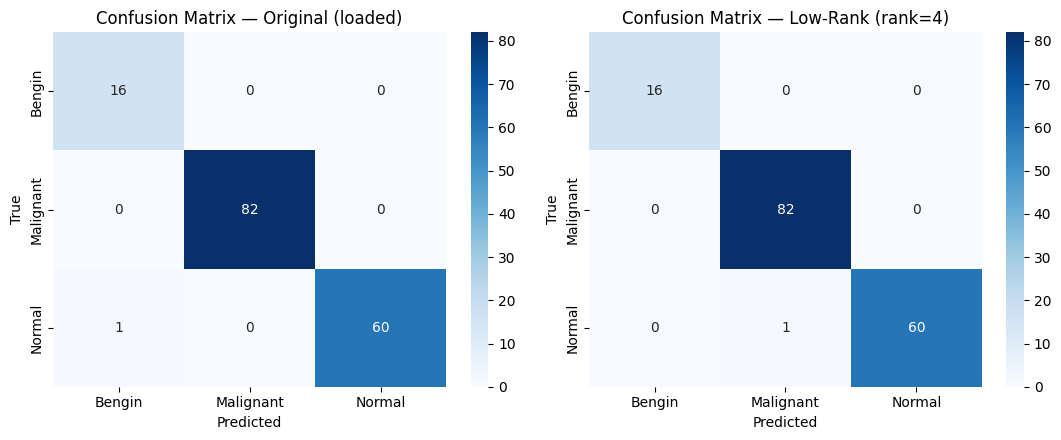

In [8]:
# ============================================================================
# RESOURCE / SIZE / METRIC COMPARISON TABLES
# ============================================================================
size_orig_total = orig_size_cnn + orig_size_svm + orig_size_scaler
size_lr_kb      = get_file_size_kb(paths_lr["cnn"])
size_lr_gz_kb   = get_file_size_kb(paths_lr["cnn_gz"])
size_lr_total   = (size_lr_kb +
                   get_file_size_kb("artifacts/svm_lowrank.pkl") +
                   get_file_size_kb("artifacts/scaler_lowrank.pkl"))
size_lr_gz_total = (size_lr_gz_kb +
                    get_file_size_kb("artifacts/svm_lowrank.pkl") +
                    get_file_size_kb("artifacts/scaler_lowrank.pkl"))

res_df = resource_table([
    ("Original",
     size_orig_total, model_orig.count_params(),
     metrics_orig["feat_time"], metrics_orig["inf_time"]),
    ("Low-Rank (.keras)",
     size_lr_total, model_lr.count_params(),
     metrics_lr["feat_time"], metrics_lr["inf_time"]),
    ("Low-Rank (.keras.gz)",
     size_lr_gz_total, model_lr.count_params(),
     metrics_lr["feat_time"], metrics_lr["inf_time"]),
])
print("\n" + "=" * 78)
print("RESOURCE COMPARISON")
print("=" * 78)
print(res_df.to_string(index=False))

size_df = pd.DataFrame([
    ["CNN Attention (main)", orig_size_cnn   , size_lr_kb       , size_lr_gz_kb],
    ["SVM Classifier"      , orig_size_svm   , get_file_size_kb("artifacts/svm_lowrank.pkl"   ), get_file_size_kb("artifacts/svm_lowrank.pkl"   )],
    ["Feature Scaler"      , orig_size_scaler, get_file_size_kb("artifacts/scaler_lowrank.pkl"), get_file_size_kb("artifacts/scaler_lowrank.pkl")],
], columns=["Komponen", "Awal (KB)", "Low-Rank (KB)", "Low-Rank+GZIP (KB)"])
size_df.loc[len(size_df)] = ["TOTAL",
                             size_df["Awal (KB)"].sum(),
                             size_df["Low-Rank (KB)"].sum(),
                             size_df["Low-Rank+GZIP (KB)"].sum()]
print("\nFILE-LEVEL SIZE COMPARISON")
print(size_df.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

summary_df = pd.DataFrame({
    "Metric"  : ["Accuracy", "Sensitivity (mean)", "Specificity (mean)",
                 "F1-Score (mean)", "AUC (macro)"],
    "Original": [
        f'{metrics_orig["accuracy"]:.4f}',
        f'{np.mean(metrics_orig["sensitivity"]):.4f}',
        f'{np.mean(metrics_orig["specificity"]):.4f}',
        f'{np.mean(metrics_orig["f1"          ]):.4f}',
        f'{metrics_orig["auc_macro"]:.4f}',
    ],
    "Low-Rank": [
        f'{metrics_lr["accuracy"]:.4f}',
        f'{np.mean(metrics_lr["sensitivity"]):.4f}',
        f'{np.mean(metrics_lr["specificity"]):.4f}',
        f'{np.mean(metrics_lr["f1"          ]):.4f}',
        f'{metrics_lr["auc_macro"]:.4f}',
    ],
})
print("\n" + "=" * 78)
print("METRIC SUMMARY (Original vs Low-Rank)")
print("=" * 78)
print(summary_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_confusion_matrix(metrics_orig, class_names, ax=axes[0])
plot_confusion_matrix(metrics_lr  , class_names, ax=axes[1])
plt.tight_layout(); plt.show()


In [9]:
# ============================================================================
# SAVE LOW-RANK ARTEFACTS TO NEW FOLDER
# ============================================================================
from datetime import datetime
out_folder = f"saved_models_lowrank_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(out_folder, exist_ok=True)

shutil.copy2(paths_lr["cnn"]      , os.path.join(out_folder, "cnn_attention_model_lowrank.keras"))
shutil.copy2(paths_lr["extractor"], os.path.join(out_folder, "feature_extractor_lowrank.keras"))
shutil.copy2("artifacts/svm_lowrank.pkl"   , os.path.join(out_folder, "svm_classifier_lowrank.pkl"))
shutil.copy2("artifacts/scaler_lowrank.pkl", os.path.join(out_folder, "feature_scaler_lowrank.pkl"))

with open(os.path.join(out_folder, "training_history_lowrank.json"), "w") as f:
    json.dump({k: [float(x) for x in v] for k, v in hist_lr.history.items()},
              f, indent=2)

print(f"Low-rank artefacts saved to {out_folder}/")
for fn in sorted(os.listdir(out_folder)):
    fp = os.path.join(out_folder, fn)
    print(f"  {fn:<40} {get_file_size_kb(fp):>10.2f} KB")


Low-rank artefacts saved to saved_models_lowrank_20260428_120309/
  cnn_attention_model_lowrank.keras           9970.11 KB
  feature_extractor_lowrank.keras             3333.73 KB
  feature_scaler_lowrank.pkl                     0.98 KB
  svm_classifier_lowrank.pkl                     9.55 KB
  training_history_lowrank.json                  0.37 KB
